# Clustering Tuning Explorer

Esplorazione interattiva di sweep di tuning **già eseguite**.

## Indice

- [Agglomerative](#Agglomerative) — 0. scegli embedding · 1. metric (interclass matrix) · 2. linkage (dendrogrammi) · 3. n_clusters · 4. artefatto · 5. ARI/NMI · 6. subsampling stability · 7. vista multi-embedding
- [GMM](#GMM) — 0. scegli embedding · 1. stabilità init · 2. covariance_type · 3. n_components · 4. artefatto · 5. vista multi-embedding
- [KMeans](#KMeans) — 0. scegli embedding · 1. stabilità init · 2. n_clusters · 3. artefatto · 4. vista multi-embedding
- [HDBSCAN](#HDBSCAN) — 0. scegli embedding · 1. min_cluster_size × min_samples · 2. noise_fraction · 3. artefatto · 4. vista multi-embedding
- [Spectral](#Spectral) — 0. scegli embedding · 1. affinity + iperparametro · 2. n_clusters/eigengap · 3. artefatto · 4. vista multi-embedding

## Helper

In [36]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Repo root isn't on sys.path when this notebook runs with cwd=notebooks/post-results_analysis/ -
# same fix as clustering_evaluation.ipynb / temp/*/run_prototype.py.
NOTEBOOK_REPO_ROOT = Path.cwd().resolve().parents[1]
if str(NOTEBOOK_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_REPO_ROOT))

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

In [37]:

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from src.analysis.clustering import CLUSTERING_METHODS
from src.analysis.consensus_clustering import subsampling_stability_index
from src.utils.artifacts import load_matrix


def show_images(run_dir: Path, image_names: list[str]) -> None:
    """Displays one or more diagnostic images from the same run side by side (e.g. one
    dendrogram per linkage, or a single interclass_distance_matrix.png). Raises if any
    is missing rather than skipping it."""
    fig, axes = plt.subplots(1, len(image_names), figsize=(7 * len(image_names), 7))
    axes = [axes] if len(image_names) == 1 else axes
    for ax, image_name in zip(axes, image_names):
        image_path = run_dir / image_name
        if not image_path.is_file():
            raise FileNotFoundError(f"{image_name!r} not found in {run_dir}")
        ax.imshow(plt.imread(image_path))
        ax.set_title(image_name, fontsize=10)
        ax.axis("off")
    fig.tight_layout()
    plt.show()


def load_tuning_results(run_dirs: list[Path]) -> pd.DataFrame:
    """Reads tuning_results.csv from each run dir and concatenates them, tagged by a
    `run` column (the run dir's own name, e.g. "27-08_s1.1_euclidean_n10")."""
    frames = []
    for run_dir in run_dirs:
        csv_path = run_dir / "tuning_results.csv"
        if not csv_path.is_file():
            raise FileNotFoundError(f"no tuning_results.csv in {run_dir}")
        df = pd.read_csv(csv_path)
        df.insert(0, "run", run_dir.name)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def list_combo_keys(run_dir: Path) -> list[str]:
    """Lists every combination key saved in a run's clusterings.npz (save_tuning_clusterings:
    true), e.g. "n_clusters=2,linkage=average,metric=cosine" - use to find the exact key for
    crosstab_run below."""
    npz_path = run_dir / "clusterings.npz"
    if not npz_path.is_file():
        raise FileNotFoundError(f"no clusterings.npz in {run_dir} - rerun tuning with save_tuning_clusterings=true")
    return sorted(np.load(npz_path).keys())


def crosstab_run(run_dir: Path, combo_key: str, metadata_column: str) -> pd.DataFrame:
    """Cross-tabulates one tuning combination's cluster labels against a metadata column,
    to check whether a candidate n_clusters is tracking a known confound (e.g. lesion_side)
    instead of genuine structure. `combo_key` must match a key in clusterings.npz exactly -
    see list_combo_keys(run_dir)."""
    npz_path = run_dir / "clusterings.npz"
    if not npz_path.is_file():
        raise FileNotFoundError(f"no clusterings.npz in {run_dir} - rerun tuning with save_tuning_clusterings=true")
    metadata_path = run_dir / "metadata.csv"
    if not metadata_path.is_file():
        raise FileNotFoundError(f"no metadata.csv in {run_dir}")

    z = np.load(npz_path)
    if combo_key not in z:
        raise KeyError(f"{combo_key!r} not in {npz_path} - available keys: {sorted(z.keys())}")
    labels = z[combo_key]

    metadata = pd.read_csv(metadata_path)
    if metadata_column not in metadata.columns:
        raise KeyError(f"{metadata_column!r} not a column in {metadata_path} - available: {list(metadata.columns)}")

    return pd.crosstab(labels, metadata[metadata_column])

def compare_combos(run_dir: Path, combo_key_a: str, combo_key_b: str) -> dict[str, float]:
    """ARI + NMI between two combinations' cluster labels from the same run's
    clusterings.npz - quantifies "how similar are these two candidates" instead of eyeballing
    two crosstabs side by side (e.g. does average/ward really converge on the same partition,
    or just look similar?). Raises if either key is missing."""
    npz_path = run_dir / "clusterings.npz"
    if not npz_path.is_file():
        raise FileNotFoundError(f"no clusterings.npz in {run_dir} - rerun tuning with save_tuning_clusterings=true")
    z = np.load(npz_path)
    for key in (combo_key_a, combo_key_b):
        if key not in z:
            raise KeyError(f"{key!r} not in {npz_path} - available keys: {sorted(z.keys())}")
    labels_a, labels_b = z[combo_key_a], z[combo_key_b]
    return {
        "ari": adjusted_rand_score(labels_a, labels_b),
        "nmi": normalized_mutual_info_score(labels_a, labels_b),
    }


def _read_tuning_config(run_dir: Path) -> dict:
    """Parses the JSON config block embedded in a tuning run's config.md (a fenced ```json
    block) - a different format from production's "Params used:" line
    (src.utils.artifacts.read_run_params), so not directly reusable here."""
    config_path = run_dir / "config.md"
    if not config_path.is_file():
        raise FileNotFoundError(f"no config.md in {run_dir}")
    text = config_path.read_text()
    if "```json" not in text:
        raise ValueError(f"{config_path} has no ```json config block")
    block = text.split("```json", 1)[1].split("```", 1)[0]
    return json.loads(block)


def _parse_combo_key(combo_key: str) -> dict:
    """Converts a clusterings.npz key like "n_clusters=5,linkage=average,metric=euclidean"
    into a params dict for CLUSTERING_METHODS, casting each value to int/float when possible,
    else leaving it as a string."""
    params = {}
    for part in combo_key.split(","):
        name, value = part.split("=")
        try:
            params[name] = int(value)
        except ValueError:
            try:
                params[name] = float(value)
            except ValueError:
                params[name] = value
    return params


def stability_check(run_dir: Path, combo_key: str, subsample_fraction: float = 0.8) -> float:
    """Subsampling Stability Index (see clustering_evaluation.ipynb §5) for one tuning
    combination - refits the same method/params on an 80% subsample of the same embedding
    this run swept over (its own config.md `input_path`, loaded via load_matrix - the same
    contract clustering.py/embedding_app.py use) and scores ARI against a full-sample fit.
    Doesn't require a production run to exist first - works directly on a tuning combo.
    A value near 1 means the clustering doesn't depend on which subjects happened to be
    sampled; a low value is a reason to look closer, not to discard the candidate outright."""
    config = _read_tuning_config(run_dir)
    input_path = NOTEBOOK_REPO_ROOT / config["input_path"]

    X, embedding_metadata, _extra_arrays = load_matrix(input_path)
    tuning_metadata = pd.read_csv(run_dir / "metadata.csv")
    if not embedding_metadata["subject_id"].equals(tuning_metadata["subject_id"]):
        raise ValueError(
            f"{input_path}'s subject_id order doesn't match {run_dir}/metadata.csv - "
            "can't reuse X positionally for this run"
        )

    return subsampling_stability_index(config["clustering_method"], X, _parse_combo_key(combo_key), subsample_fraction)


def crosstab_refit(run_dir: Path, params: dict, metadata_column: str) -> pd.DataFrame:
    """Same purpose as crosstab_run, for a run with no saved clusterings.npz (spectral with
    `affinity` swept has save_tuning_clusterings disabled by design, docs/dev/models.md) -
    refits the given combination directly via CLUSTERING_METHODS instead of reading saved
    labels. `params` is a plain dict (e.g. {"n_clusters": 6, "affinity": "rbf", "gamma": 1.0}),
    not a clusterings.npz key string - there is no saved key to copy from here."""
    config = _read_tuning_config(run_dir)
    X, metadata, _extra_arrays = load_matrix(NOTEBOOK_REPO_ROOT / config["input_path"])
    if metadata_column not in metadata.columns:
        raise KeyError(f"{metadata_column!r} not a column in metadata - available: {list(metadata.columns)}")
    labels = CLUSTERING_METHODS[config["clustering_method"]](X, params)
    return pd.crosstab(labels, metadata[metadata_column])

## Agglomerative

### 0. Scegli l'embedding da analizzare

Un solo `RUN_DIR` alla volta per le sezioni 1-6 (metric → linkage → n_clusters → artefatto →
confronto tra combinazioni → stabilità) - il confronto tra più embedding è in fondo, sezione 7.

Esempio: `27-08_s1.1_euclidean_n3` - non ancora controllata nelle sessioni precedenti
(`n2`/`n10` euclidean e tutti e 3 i `dice` erano già stati fatti).

In [38]:
RUN_DIR = NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/agglomerative/27-08_s1.1_euclidean_n3"

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"run directory not found: {RUN_DIR}")

results = pd.read_csv(RUN_DIR / "tuning_results.csv")
print(f"{len(results)} righe, metric sweepate: {sorted(results['metric'].unique())}, linkage sweepate: {sorted(results['linkage'].unique())}")

70 righe, metric sweepate: ['cosine', 'euclidean', 'manhattan'], linkage sweepate: ['average', 'complete', 'single', 'ward']


### 1. Quale `metric` guardare per prima? (interclass distance matrix)

**Cosa mostra:** un heatmap per ogni `metric` sweepata (euclidean/cosine/manhattan) — righe/colonne = valori di `dataset`, cella = distanza media tra i soggetti dei due gruppi (diagonale = dentro lo stesso `dataset`). Pre-check indipendente dal fit, non dice nulla su `n_clusters`.
**Come leggerlo:** la `metric` migliore tiene la diagonale bassa e le celle fuori diagonale alte.

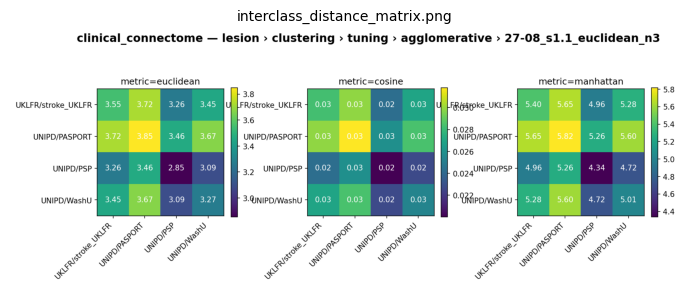

In [39]:
show_images(RUN_DIR, ["interclass_distance_matrix.png"])

### 2. `linkage`, dato un `metric` (dendrogrammi)

**Cosa mostra:** un file per `metric` sweepata, un subplot per `linkage` valido — dendrogramma troncato alle ultime 30 fusioni (non l'albero completo), asse y = distanza di fusione.
**Come leggerlo:** il salto verticale più grande tra due fusioni indica il taglio più naturale (vicino alla cima → 2 cluster). `single` va quasi sempre scartato (chaining) — guardalo comunque, non darlo per scontato.

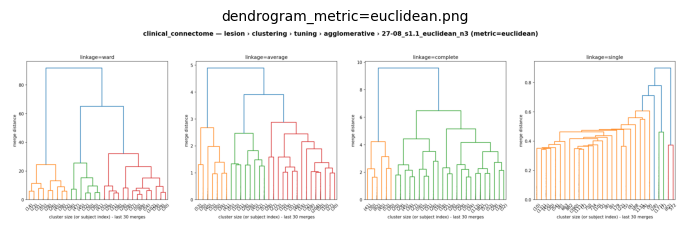

In [40]:
METRIC = "euclidean"
show_images(RUN_DIR, [f"dendrogram_metric={METRIC}.png"])

### 3. `n_clusters`, dentro il `metric` scelto

**Cosa mostra:** tabella `results` filtrata sulla `metric` scelta in sezione 1 (`single` escluso) — Silhouette/Calinski-Harabasz/Davies-Bouldin per ogni `n_clusters`/`linkage`. Nessun plot qui: 3 parametri sweepati insieme (`n_clusters`×`linkage`×`metric`) sono troppi per un grafico aggregato (CH/DB sono `NaN` se `metric != "euclidean"` — non è un bug).
**Come leggerlo:** Silhouette vicino a 1 = cluster compatti/separati (unico dei tre interpretabile da solo); CH cresce quasi sempre con k (solo conferma); DB più basso = meglio.

In [41]:
METRIC = "euclidean"

(
    results[(results["metric"] == METRIC) & (results["linkage"] != "single")]
    .sort_values(["linkage", "n_clusters"])
)

,n_clusters,linkage,metric,silhouette,noise_fraction,calinski_harabasz,davies_bouldin
1,2,average,euclidean,0.451849,0.0,957.999591,0.764335
11,3,average,euclidean,0.481164,0.0,1443.829287,0.778949
21,4,average,euclidean,0.443743,0.0,1164.372858,0.764730
31,5,average,euclidean,0.434641,0.0,1079.318691,0.737092
41,6,average,euclidean,0.423775,0.0,1078.688298,0.759393
51,8,average,euclidean,0.445557,0.0,1255.366407,0.732231
61,10,average,euclidean,0.432104,0.0,1253.265280,0.676712
4,2,complete,euclidean,0.451849,0.0,957.999591,0.764335
14,3,complete,euclidean,0.480582,0.0,1458.285122,0.785972
24,4,complete,euclidean,0.429988,0.0,1185.718365,0.802358


### 4. Check artefatto: crosstab del `k` candidato contro i metadati

**Cosa mostra:** quanti soggetti di ogni cluster cadono in ciascuna categoria di una colonna di metadati (es. `lesion_side`).
**Come leggerlo:** se un cluster è quasi tutto in una sola categoria, quel `k` sta solo ritrovando un'informazione già nei metadati, non struttura nuova.

In [42]:
list_combo_keys(RUN_DIR)[:10]  # per trovare il COMBO_KEY esatto sotto

['n_clusters=10,linkage=average,metric=cosine',
 'n_clusters=10,linkage=average,metric=euclidean',
 'n_clusters=10,linkage=average,metric=manhattan',
 'n_clusters=10,linkage=complete,metric=cosine',
 'n_clusters=10,linkage=complete,metric=euclidean',
 'n_clusters=10,linkage=complete,metric=manhattan',
 'n_clusters=10,linkage=single,metric=cosine',
 'n_clusters=10,linkage=single,metric=euclidean',
 'n_clusters=10,linkage=single,metric=manhattan',
 'n_clusters=10,linkage=ward,metric=euclidean']

In [43]:
COMBO_KEY = "n_clusters=2,linkage=complete,metric=cosine"
METADATA_COLUMN = "lesion_side"

crosstab_run(RUN_DIR, COMBO_KEY, METADATA_COLUMN)

lesion_side,left,right,unknown
row_0,,,
0,397,409,166
1,148,0,30


### 5. Confronto quantitativo tra combinazioni (ARI/NMI)

**Cosa mostra:** accordo tra due partizioni della stessa sweep (es. due `linkage` allo stesso `k`, o due `k` vicini) — sostituisce il confronto a occhio tra due crosstab.

**Come leggerlo:** 0 = nessun accordo oltre il caso, 1 = partizioni identiche.

In [44]:
COMBO_KEY_A = "n_clusters=5,linkage=average,metric=euclidean"
COMBO_KEY_B = "n_clusters=5,linkage=ward,metric=euclidean"

compare_combos(RUN_DIR, COMBO_KEY_A, COMBO_KEY_B)

{'ari': 0.682123488224098, 'nmi': 0.8138802407397145}

### 6. Subsampling Stability Index

**Cosa mostra:** ARI tra il fit sul 100% dei soggetti e un rifit sull'80% (subsample casuale, senza reinserimento).

**Come leggerlo:** vicino a 1 = il clustering non dipende da chi capita nel campione (es. outlier); basso = segnale da approfondire, non un motivo per scartare subito il candidato.

In [45]:
COMBO_KEY = "n_clusters=5,linkage=ward,metric=euclidean"

stability_check(RUN_DIR, COMBO_KEY, subsample_fraction=0.8)

0.9595809292930771

### 7. Vista globale multi-embedding

**Cosa mostra:** lo stesso check (tabella o immagine) fianco a fianco su più `RUN_DIRS` (`n_components`/`metric` diversi) — solo dopo aver fatto 1-4 su ciascun embedding separatamente.

**Come leggerlo:** solo qualitativo, spazi diversi non sono numericamente confrontabili — serve a vedere se un `k` sopravvissuto al check si ripete su più embedding.

In [46]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/agglomerative/27-08_s1.1_euclidean_n2",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/agglomerative/27-08_s1.1_euclidean_n3",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/agglomerative/27-08_s1.1_euclidean_n10",
]
for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

all_results = load_tuning_results(RUN_DIRS)
print(f"{len(all_results)} righe, run: {sorted(all_results['run'].unique())}")
all_results[all_results["linkage"] != "single"].sort_values("silhouette", ascending=False).groupby(["run", "metric"]).head(1)

210 righe, run: ['27-08_s1.1_euclidean_n10', '27-08_s1.1_euclidean_n2', '27-08_s1.1_euclidean_n3']


,run,n_clusters,linkage,metric,silhouette,noise_fraction,calinski_harabasz,davies_bouldin
12,27-08_s1.1_euclidean_n2,3,average,cosine,0.750781,0.0,NaN,NaN
75,27-08_s1.1_euclidean_n3,2,complete,cosine,0.730168,0.0,NaN,NaN
162,27-08_s1.1_euclidean_n10,4,average,cosine,0.665396,0.0,NaN,NaN
31,27-08_s1.1_euclidean_n2,5,average,euclidean,0.496595,0.0,1384.734553,0.618362
43,27-08_s1.1_euclidean_n2,6,average,manhattan,0.491239,0.0,NaN,NaN
83,27-08_s1.1_euclidean_n3,3,average,manhattan,0.487295,0.0,NaN,NaN
80,27-08_s1.1_euclidean_n3,3,ward,euclidean,0.481611,0.0,1460.136715,0.784455
164,27-08_s1.1_euclidean_n10,4,complete,euclidean,0.445590,0.0,1006.928463,0.787231
163,27-08_s1.1_euclidean_n10,4,average,manhattan,0.440317,0.0,NaN,NaN


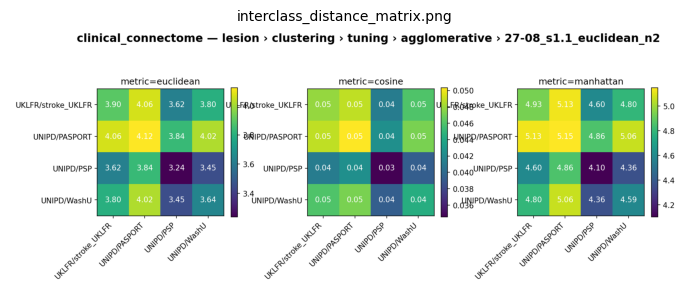

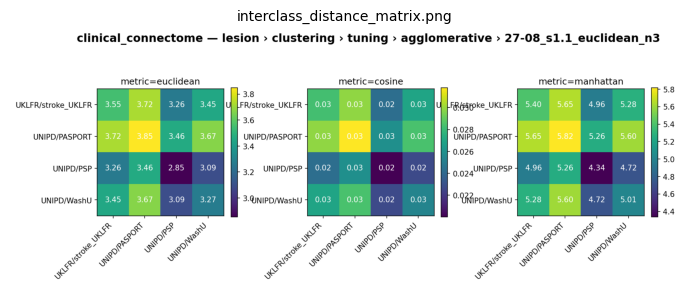

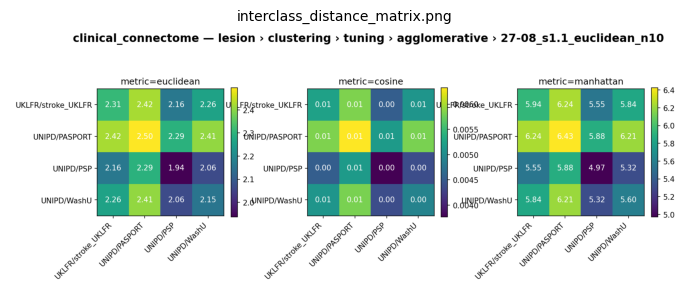

In [47]:
IMAGE_NAME = "interclass_distance_matrix.png"
for run_dir in RUN_DIRS:
    show_images(run_dir, [IMAGE_NAME])

## GMM

Ordine diverso da agglomerative: **stabilità prima di tutto** (GMM converge a un ottimo *locale*
via EM, dipende dal seed più di quanto n_clusters da solo suggerisca), poi `covariance_type`
(comparabile direttamente via BIC/AIC, niente pre-check dedicato tipo interclass-matrix), poi
`n_components`, poi il solito check artefatto.

### 0. Scegli l'embedding

Stesso discorso di agglomerative: `dice`/`euclidean` × `n_components` (UMAP) non sono
comparabili numericamente tra loro, solo qualitativamente.

In [48]:
RUN_DIR = NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/gmm/27-08_s1.1_euclidean_n2"

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"run directory not found: {RUN_DIR}")

results = pd.read_csv(RUN_DIR / "tuning_results.csv")
print(
    f"{len(results)} righe, covariance_type sweepate: {sorted(results['covariance_type'].unique())}, "
    f"n_components sweepate: {sorted(results['n_components'].unique())}"
)

28 righe, covariance_type sweepate: ['diag', 'full', 'spherical', 'tied'], n_components sweepate: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10)]


### 1. Stabilità dell'inizializzazione (`init_params`/`n_init`)

**Cosa mostra:** `stability_plot.png` 
    — BIC per 3 `n_components` rappresentativi (min/mediana/max della griglia)
    una linea per `init_params` (`kmeans` vs `random`), errorbar su `n_init`.

**Come leggerlo:** una linea che si appiattisce presto e resta bassa = inizializzazione stabile; se resta alta, i punteggi della sweep principale per quel `n_components` dipendono più dal seed che dal vero numero di cluster.

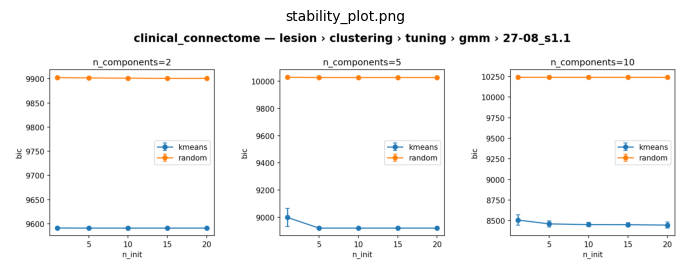

In [49]:
show_images(RUN_DIR, ["stability_plot.png"])

### 2. `covariance_type`

**Cosa mostra:** `tuning_plot.png` — heatmap, un subplot per Silhouette/CH/DB/BIC/AIC, asse x = `n_components`, asse y = `covariance_type`, colore = valore della metrica.
**Come leggerlo:** per BIC/AIC più basso = meglio — a differenza di agglomerative, qui sono lo strumento statistico corretto per confrontare `covariance_type` (penalizzano la complessità del modello). Guarda quale riga (`covariance_type`) ha in media i colori migliori lungo `n_components`.

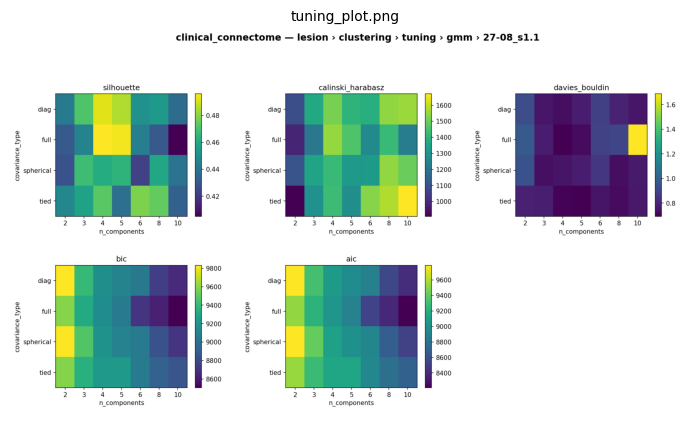

In [50]:
show_images(RUN_DIR, ["tuning_plot.png"])

In [51]:
results.sort_values(["covariance_type", "n_components"])

,n_components,covariance_type,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,bic,aic
2,2,diag,0.442228,1092.204320,0.929604,0.0,9831.810014,9786.382359
6,3,diag,0.471016,1372.833643,0.753915,0.0,9396.486572,9325.821331
10,4,diag,0.491844,1515.296233,0.729169,0.0,9164.985720,9069.082892
14,5,diag,0.485236,1404.504398,0.767515,0.0,9096.706679,8975.566266
18,6,diag,0.450979,1386.840537,0.880089,0.0,9042.225542,8895.847543
22,8,diag,0.454197,1545.548765,0.793463,0.0,8751.318158,8554.464987
26,10,diag,0.437117,1554.943156,0.751870,0.0,8664.252008,8416.923664
0,2,full,0.430722,986.510701,0.969441,0.0,9591.249782,9535.727093
4,3,full,0.445754,1210.735417,0.767364,0.0,9317.550732,9231.742939
8,4,full,0.496008,1549.377925,0.692717,0.0,9152.616139,9036.523243


### 3. `n_components`

**Cosa mostra:** dalla tabella `results`, il `n_components` a Silhouette più alta per ciascun `covariance_type` (non ricalcolato da BIC/AIC in questa cella).
**Come leggerlo:** confronta questo pick con la heatmap BIC/AIC della sezione 2 — se non coincidono (Silhouette alto ma BIC lontano dal minimo per quella riga), preferisci BIC/AIC come criterio primario, è quello statisticamente corretto per questo confronto.

In [52]:
results.sort_values("silhouette", ascending=False).groupby("covariance_type").head(1)

,n_components,covariance_type,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,bic,aic
8,4,full,0.496008,1549.377925,0.692717,0.0,9152.616139,9036.523243
10,4,diag,0.491844,1515.296233,0.729169,0.0,9164.985720,9069.082892
17,6,tied,0.477900,1532.269527,0.748885,0.0,9048.719619,8947.769275
7,3,spherical,0.467701,1354.214866,0.732170,0.0,9472.755176,9417.232487


### 4. Check artefatto: crosstab del candidato contro i metadati

Stesso check della sezione 4 di agglomerative: un cluster quasi puro su una categoria di metadati = artefatto, non struttura nuova.

In [53]:
list_combo_keys(RUN_DIR)[:10]  # per trovare il COMBO_KEY esatto sotto

['n_components=10,covariance_type=diag',
 'n_components=10,covariance_type=full',
 'n_components=10,covariance_type=spherical',
 'n_components=10,covariance_type=tied',
 'n_components=2,covariance_type=diag',
 'n_components=2,covariance_type=full',
 'n_components=2,covariance_type=spherical',
 'n_components=2,covariance_type=tied',
 'n_components=3,covariance_type=diag',
 'n_components=3,covariance_type=full']

In [54]:
COMBO_KEY = "n_components=4,covariance_type=full"
METADATA_COLUMN = "lesion_side"

crosstab_run(RUN_DIR, COMBO_KEY, METADATA_COLUMN)

lesion_side,left,right,unknown
row_0,,,
0,210,143,78
1,216,0,49
2,1,247,41
3,118,19,28


### 5. Vista globale multi-embedding

**Cosa mostra:** lo stesso check (tabella e `stability_plot.png`) fianco a fianco su più `RUN_DIRS` (`n_components` diversi, `metric=euclidean`) — miglior `n_components` per Silhouette in ciascun `covariance_type`, per ciascun embedding.
**Come leggerlo:** solo qualitativo, spazi diversi non sono numericamente confrontabili — serve a vedere se un candidato (`n_components`, `covariance_type`) sopravvissuto al check si ripete su più embedding.

In [ ]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/gmm/27-08_s1.1_euclidean_n2",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/gmm/27-08_s1.1_euclidean_n3",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/gmm/27-08_s1.1_euclidean_n10",
]
for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

all_results = load_tuning_results(RUN_DIRS)
print(f"{len(all_results)} righe, run: {sorted(all_results['run'].unique())}")
all_results.sort_values("silhouette", ascending=False).groupby(["run", "covariance_type"]).head(1)

In [ ]:
IMAGE_NAME = "stability_plot.png"
for run_dir in RUN_DIRS:
    show_images(run_dir, [IMAGE_NAME])

## KMeans

Il più semplice dei 5: un solo parametro sweepato (`n_clusters`), niente equivalente di
`metric`/`covariance_type` da gestire. Stessa ragione di GMM per la stabilità (EM/inizializzazione
casuale → minimo locale dell'inerzia), quindi stessa priorità: stabilità prima di tutto.

### 0. Scegli l'embedding

In [55]:
RUN_DIR = NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/kmeans/27-08_s1.1_euclidean_n2"

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"run directory not found: {RUN_DIR}")

results = pd.read_csv(RUN_DIR / "tuning_results.csv")
print(f"{len(results)} righe, n_clusters sweepate: {sorted(results['n_clusters'].unique())}")

7 righe, n_clusters sweepate: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10)]


### 1. Stabilità dell'inizializzazione (`init`/`n_init`)

**Cosa mostra:** `stability_plot.png` — 3 pannelli, uno per ogni `n_clusters` rappresentativo (min/mediana/max della griglia). In ogni pannello: asse x = `n_init`, asse y = inertia (media ± deviazione standard su più ripetizioni a seed diversi), una linea per `init` (`k-means++` vs `random`).
**Come leggerlo:** una linea che si appiattisce presto e resta bassa = l'inerzia non dipende più dal seed, inizializzazione stabile.

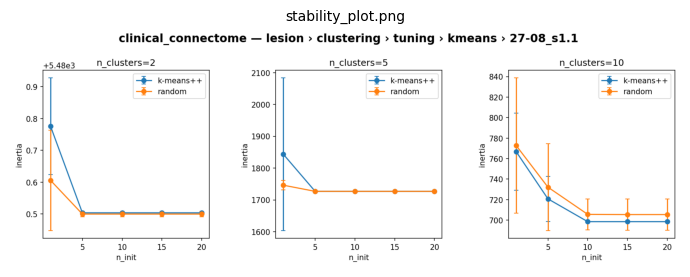

In [56]:
show_images(RUN_DIR, ["stability_plot.png"])

### 2. `n_clusters`

**Cosa mostra:** `tuning_plot.png` — un subplot per Silhouette/CH/DB/`inertia`, tutti con asse x = `n_clusters` (`inertia` è l'elbow plot: stessa colonna già in tabella, nessun file a parte).
**Come leggerlo:** `inertia` scende sempre con k — cerca il gomito (dove smette di scendere ripidamente), non il minimo, e incrocialo con Silhouette.

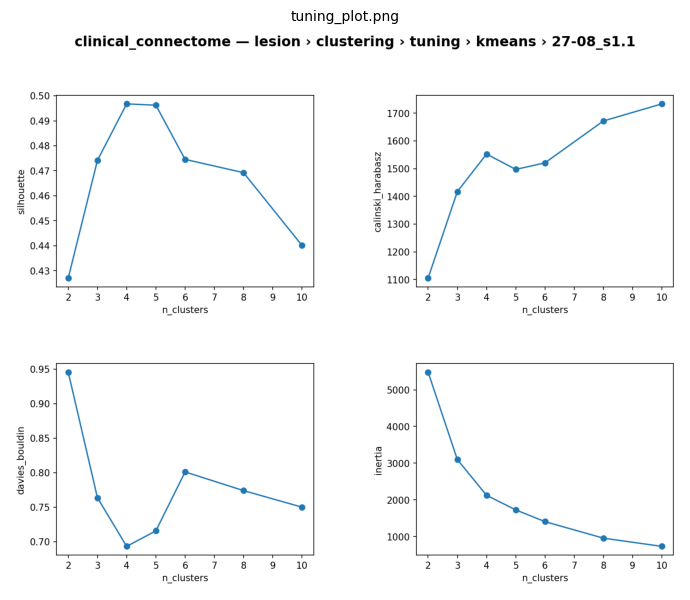

In [57]:
show_images(RUN_DIR, ["tuning_plot.png"])

In [58]:
results.sort_values("silhouette", ascending=False)

,n_clusters,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,inertia
2,4,0.496778,1552.576348,0.693189,0.0,2124.305664
3,5,0.496249,1497.120304,0.715661,0.0,1726.805664
4,6,0.474556,1520.819913,0.801072,0.0,1406.893188
1,3,0.474174,1417.023980,0.763601,0.0,3099.599121
5,8,0.469242,1671.707911,0.773990,0.0,956.548096
6,10,0.440134,1733.313508,0.750048,0.0,732.645142
0,2,0.427023,1105.405585,0.945606,0.0,5480.843750


### 3. Check artefatto: crosstab del candidato contro i metadati

**Come leggerlo:** un cluster quasi puro su una categoria di metadati (`lesion_side`, `dataset`) = artefatto, non struttura nuova.

In [59]:
list_combo_keys(RUN_DIR)[:10]  # per trovare il COMBO_KEY esatto sotto

['n_clusters=10',
 'n_clusters=2',
 'n_clusters=3',
 'n_clusters=4',
 'n_clusters=5',
 'n_clusters=6',
 'n_clusters=8']

In [60]:
COMBO_KEY = "n_clusters=5"
METADATA_COLUMN = "lesion_side"

crosstab_run(RUN_DIR, COMBO_KEY, METADATA_COLUMN)

lesion_side,left,right,unknown
row_0,,,
0,211,124,70
1,215,0,49
2,1,144,34
3,118,24,29
4,0,117,14


### 4. Vista globale multi-embedding

**Cosa mostra:** lo stesso check (tabella e `tuning_plot.png`) fianco a fianco su più `RUN_DIRS` — miglior `n_clusters` per Silhouette in ciascun embedding.
**Come leggerlo:** solo qualitativo — serve a vedere se il `k` migliore converge o cambia al variare di `n_components`.

In [ ]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/kmeans/27-08_s1.1_euclidean_n2",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/kmeans/27-08_s1.1_euclidean_n3",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/kmeans/27-08_s1.1_euclidean_n10",
]
for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

all_results = load_tuning_results(RUN_DIRS)
print(f"{len(all_results)} righe, run: {sorted(all_results['run'].unique())}")
all_results.sort_values("silhouette", ascending=False).groupby("run").head(1)

In [ ]:
IMAGE_NAME = "tuning_plot.png"
for run_dir in RUN_DIRS:
    show_images(run_dir, [IMAGE_NAME])

## HDBSCAN

L'unico dei 5 senza check di stabilità (deterministico, no `random_state`, come agglomerative) E
senza un pre-check dedicato sul secondo asse: `min_cluster_size` × `min_samples` sono sweepati
insieme in un solo run (decisione esplicita di design - niente run ripetute/sequenziali), letti
dalla stessa heatmap a 2 parametri già usata per agglomerative `n_clusters`×`linkage`. Nessuna
diagnostica standalone dedicata (niente DBCV/condensation tree, scelta deliberata - nemmeno
l'esempio ufficiale sklearn li usa).

### 0. Scegli l'embedding

In [61]:
RUN_DIR = NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/hdbscan/27-08_s1.1_euclidean_n2"

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"run directory not found: {RUN_DIR}")

results = pd.read_csv(RUN_DIR / "tuning_results.csv")
print(
    f"{len(results)} righe, min_cluster_size sweepate: {sorted(results['min_cluster_size'].unique())}, "
    f"min_samples sweepate: {sorted(results['min_samples'].unique())}"
)

18 righe, min_cluster_size sweepate: [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(30), np.int64(50)], min_samples sweepate: [np.int64(5), np.int64(10), np.int64(20)]


### 1. `min_cluster_size` × `min_samples`

**Cosa mostra:** `tuning_plot.png` — heatmap, un subplot per Silhouette/CH/DB/`noise_fraction`, asse x = `min_cluster_size`, asse y = `min_samples`, colore = valore della metrica.
**Come leggerlo:** cerca la cella con il colore migliore, poi controlla `noise_fraction` per quella stessa cella (sezione 2) prima di fidartene.

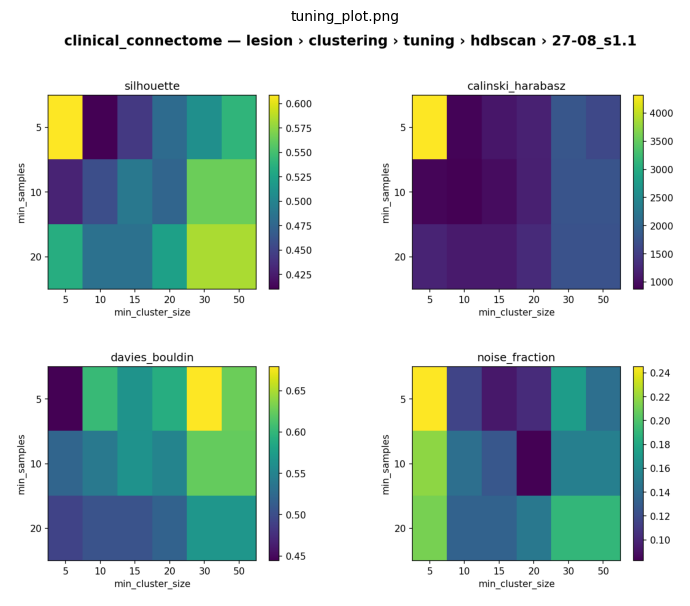

In [62]:
show_images(RUN_DIR, ["tuning_plot.png"])

In [63]:
results.sort_values("silhouette", ascending=False)

,min_cluster_size,min_samples,silhouette,calinski_harabasz,davies_bouldin,noise_fraction
0,5,5,0.608842,4321.233409,0.444315,0.245217
14,30,20,0.583874,1740.522417,0.567485,0.190435
17,50,20,0.583874,1740.522417,0.567485,0.190435
13,30,10,0.564519,1776.551589,0.623876,0.153043
16,50,10,0.564519,1776.551589,0.623876,0.153043
15,50,5,0.540031,1622.892697,0.626646,0.141739
2,5,20,0.534117,1220.829359,0.491335,0.212174
11,20,20,0.523321,1291.699687,0.518193,0.147826
12,30,5,0.509212,1798.088492,0.679241,0.172174
7,15,10,0.490025,993.838507,0.564266,0.126957


### 2. Attenzione: `noise_fraction` va letta insieme agli indici, mai da sola

**Cosa mostra:** stessa tabella di sopra, filtrata su una soglia di `noise_fraction` (quota di soggetti classificati come rumore, label `-1`).
**Come leggerlo:** un `min_cluster_size` grande può dare indici ottimi solo perché scarta molti soggetti "difficili" come rumore — i pochi rimasti sembrano ben separati. Indice alto + `noise_fraction` alta = risultato ingannevole, non un vero candidato.

In [64]:
MAX_NOISE_FRACTION = 0.1  # soglia di esempio, cambia liberamente

results[results["noise_fraction"] <= MAX_NOISE_FRACTION].sort_values("silhouette", ascending=False)

,min_cluster_size,min_samples,silhouette,calinski_harabasz,davies_bouldin,noise_fraction
10,20,10,0.474626,1174.562533,0.550082,0.082609
6,15,5,0.442889,1087.194242,0.565117,0.093043


### 3. Check artefatto: crosstab del candidato contro i metadati

**Come leggerlo:** come per gli altri metodi, più un controllo in più specifico a HDBSCAN — la riga `-1` (rumore) è mostrata a parte da `crosstab_run`: se sbilanciata per `lesion_side`/`dataset`, il rumore stesso è un artefatto, non solo i cluster.

In [65]:
list_combo_keys(RUN_DIR)[:10]  # per trovare il COMBO_KEY esatto sotto

['min_cluster_size=10,min_samples=10',
 'min_cluster_size=10,min_samples=20',
 'min_cluster_size=10,min_samples=5',
 'min_cluster_size=15,min_samples=10',
 'min_cluster_size=15,min_samples=20',
 'min_cluster_size=15,min_samples=5',
 'min_cluster_size=20,min_samples=10',
 'min_cluster_size=20,min_samples=20',
 'min_cluster_size=20,min_samples=5',
 'min_cluster_size=30,min_samples=10']

In [66]:
COMBO_KEY = "min_cluster_size=15,min_samples=10"
METADATA_COLUMN = "lesion_side"

crosstab_run(RUN_DIR, COMBO_KEY, METADATA_COLUMN)  # la riga -1 (se presente) sono i punti rumore

lesion_side,left,right,unknown
row_0,,,
-1,36,81,29
0,0,19,9
1,146,0,30
2,65,0,19
3,0,20,7
4,14,0,2
5,22,0,4
6,0,17,4
7,0,13,4


### 4. Vista globale multi-embedding

**Cosa mostra:** lo stesso check (tabella filtrata su `noise_fraction` e `tuning_plot.png`) fianco a fianco su più `RUN_DIRS` — miglior combinazione `min_cluster_size`/`min_samples` per Silhouette in ciascun embedding, sotto la stessa soglia di rumore usata in sezione 2.
**Come leggerlo:** solo qualitativo — serve a vedere se la combinazione migliore (e il suo livello di rumore) si ripete al variare di `n_components`.

In [ ]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/hdbscan/27-08_s1.1_euclidean_n2",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/hdbscan/27-08_s1.1_euclidean_n3",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/hdbscan/27-08_s1.1_euclidean_n10",
]
for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

all_results = load_tuning_results(RUN_DIRS)
print(f"{len(all_results)} righe, run: {sorted(all_results['run'].unique())}")

MAX_NOISE_FRACTION = 0.1  # stessa soglia di sezione 2, cambia liberamente
all_results[all_results["noise_fraction"] <= MAX_NOISE_FRACTION].sort_values("silhouette", ascending=False).groupby("run").head(1)

In [ ]:
IMAGE_NAME = "tuning_plot.png"
for run_dir in RUN_DIRS:
    show_images(run_dir, [IMAGE_NAME])

## Spectral

`affinity` (`nearest_neighbors`/`rbf`) è il bivio, come `metric` per agglomerative - ma qui
**non c'è un pre-check dedicato tipo interclass-matrix**: le due sotto-sweep (una per affinity,
ciascuna col proprio iperparametro `n_neighbors`/`gamma`) finiscono unite nello stesso
`tuning_plot.png`, quindi la scelta si legge direttamente da lì. Nessuno stability check
(`assign_labels: "cluster_qr"` fissato in config rimuove l'instabilità ereditata da k-means che
sklearn userebbe di default). **Nota 28-08-26**: `eigengap_affinity=<affinity>.png` ora riflette
davvero l'`affinity`/iperparametro sweepato (prima era sempre calcolato a `base_params` fisso,
stesso bug già visto e corretto per il dendrogramma di agglomerative).

### 0. Scegli l'embedding

In [67]:
RUN_DIR = NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/spectral/27-08_s1.1_euclidean_n2"

if not RUN_DIR.is_dir():
    raise FileNotFoundError(f"run directory not found: {RUN_DIR}")

results = pd.read_csv(RUN_DIR / "tuning_results.csv")
print(f"{len(results)} righe, affinity sweepate: {sorted(results['affinity'].unique())}, n_clusters sweepate: {sorted(results['n_clusters'].unique())}")

72 righe, affinity sweepate: ['nearest_neighbors', 'rbf'], n_clusters sweepate: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]


### 1. `affinity` + il suo iperparametro

**Cosa mostra:** `tuning_plot.png` — un subplot per Silhouette/CH/DB, asse x = `n_clusters`, una linea per combinazione `(affinity, iperparametro)` (es. `nearest_neighbors (n_neighbors=30)`, `rbf (gamma=1)`).
**Come leggerlo:** confronta le linee per scegliere `affinity`+iperparametro prima ancora di `n_clusters` — sotto, la tabella mostra le top-5 righe per `affinity` ordinate per Silhouette.

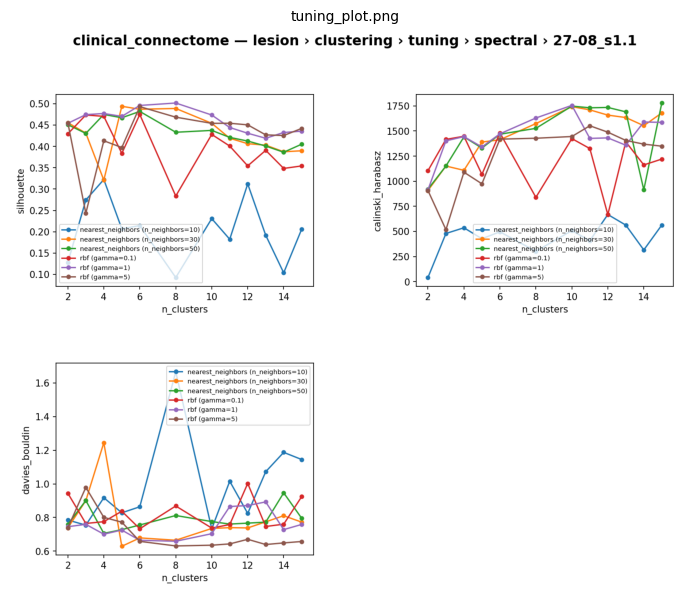

In [68]:
show_images(RUN_DIR, ["tuning_plot.png"])

In [69]:
results.sort_values("silhouette", ascending=False).groupby("affinity").head(5)

,n_clusters,n_neighbors,silhouette,calinski_harabasz,davies_bouldin,noise_fraction,affinity,gamma
52,8,NaN,0.501692,1629.855450,0.658373,0.0,rbf,1.0
49,6,NaN,0.496006,1472.142743,0.663954,0.0,rbf,1.0
10,5,30.0,0.494054,1390.091900,0.628352,0.0,nearest_neighbors,NaN
50,6,NaN,0.493193,1419.158737,0.657668,0.0,rbf,5.0
16,8,30.0,0.488942,1574.395174,0.664359,0.0,nearest_neighbors,NaN
13,6,30.0,0.487043,1413.107765,0.678292,0.0,nearest_neighbors,NaN
14,6,50.0,0.482020,1468.357101,0.755148,0.0,nearest_neighbors,NaN
43,4,NaN,0.477107,1444.313523,0.700356,0.0,rbf,1.0
8,4,50.0,0.474923,1441.699065,0.705176,0.0,nearest_neighbors,NaN
48,6,NaN,0.474782,1481.852228,0.732570,0.0,rbf,0.1


### 2. `n_clusters`, corroborato dall'eigengap

**Cosa mostra:** un file per `affinity`, un subplot per ogni valore sweepato del suo iperparametro — autovalori del grafo di affinità ordinati in ascissa, valore dell'autovalore in ordinata.
**Come leggerlo:** il k consigliato è l'indice appena prima del salto più grande tra due autovalori consecutivi (marcato nel plot). Criterio più diretto dei 3 indici generici qui, perché riflette la connettività del grafo che l'algoritmo usa internamente.

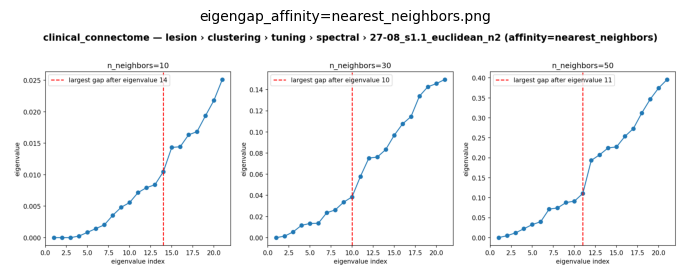

In [70]:
AFFINITY = "nearest_neighbors"
show_images(RUN_DIR, [f"eigengap_affinity={AFFINITY}.png"])

### 3. Check artefatto: crosstab del candidato contro i metadati

**Come leggerlo:** come per gli altri metodi. Nota pratica: questa run non salva `clusterings.npz` (disattivato quando `affinity` è sweepata) — serve `crosstab_refit`, che rifitta al volo invece di leggere etichette salvate.

In [71]:
PARAMS = {"n_clusters": 6, "affinity": "nearest_neighbors", "n_neighbors": 50, "assign_labels": "cluster_qr", "random_state": 0}
METADATA_COLUMN = "lesion_side"

crosstab_refit(RUN_DIR, PARAMS, METADATA_COLUMN)

lesion_side,left,right,unknown
row_0,,,
0,66,0,19
1,8,136,22
2,122,0,19
3,149,0,30
4,1,150,36
5,199,123,70


### 4. Vista globale multi-embedding

**Cosa mostra:** lo stesso check (tabella e `tuning_plot.png`) fianco a fianco su più `RUN_DIRS` — miglior combinazione `(affinity, iperparametro, n_clusters)` per Silhouette in ciascun embedding.
**Come leggerlo:** solo qualitativo — serve a vedere se `affinity`/`n_clusters` migliori si ripetono al variare di `n_components`.

In [ ]:
RUN_DIRS = [
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/spectral/27-08_s1.1_euclidean_n2",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/spectral/27-08_s1.1_euclidean_n3",
    NOTEBOOK_REPO_ROOT / "results/lesion/clustering/tuning/spectral/27-08_s1.1_euclidean_n10",
]
for run_dir in RUN_DIRS:
    if not run_dir.is_dir():
        raise FileNotFoundError(f"run directory not found: {run_dir}")

all_results = load_tuning_results(RUN_DIRS)
print(f"{len(all_results)} righe, run: {sorted(all_results['run'].unique())}")
all_results.sort_values("silhouette", ascending=False).groupby(["run", "affinity"]).head(1)

In [ ]:
IMAGE_NAME = "tuning_plot.png"
for run_dir in RUN_DIRS:
    show_images(run_dir, [IMAGE_NAME])